<a href="https://colab.research.google.com/github/IoNiCx1/MNIST_numbers/blob/main/ProjectMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


import pickle,os,warnings
warnings.filterwarnings('ignore')

print(tf.__version__)
print("GPU ->",tf.config.list_physical_devices('GPU'))

2.20.0
GPU -> [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
(x_train_full,y_train_full),(x_test,y_test) = keras.datasets.mnist.load_data()
print("Train images shape")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images shape


In [3]:
print("Train images shape:",x_train_full.shape)
print("Train labels shape:",y_train_full.shape)
print("Test images shape:",x_test.shape)
print("Test labels shape:",y_test.shape)


Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


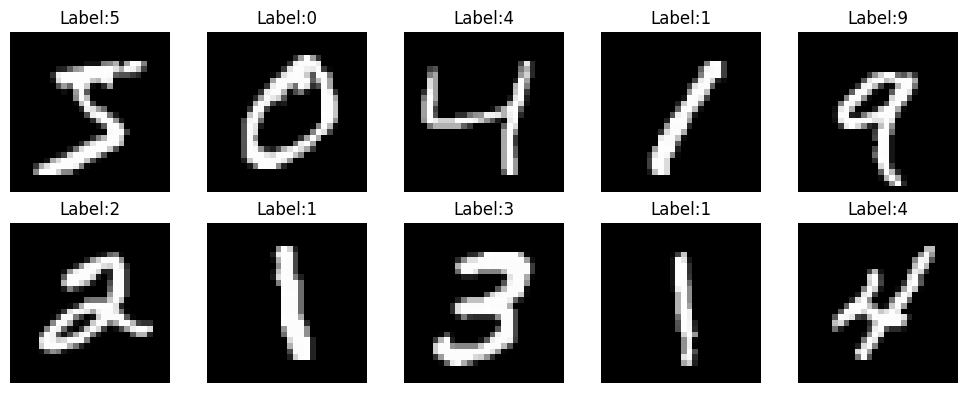

In [4]:
plt.figure(figsize=(10,4))
for i in range(10):
  plt.subplot(2,5, i+1)
  plt.imshow(x_train_full[i],cmap='gray')
  plt.title(f"Label:{y_train_full[i]}")
  plt.axis('off')
plt.tight_layout()
plt.show()


In [5]:
print("Any NaNs in train images?:",np.isnan(x_train_full).any())
print("Any NaNs in test images? :",np.isnan(x_test).any())

flat_train = x_train_full.reshape(x_train_full.shape[0],-1)
n_duplicates = len(flat_train)-len(np.unique(flat_train,axis = 0))
print("Number of Duplicate images in training set:",n_duplicates)

Any NaNs in train images?: False
Any NaNs in test images? : False
Number of Duplicate images in training set: 0


0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
dtype: int64


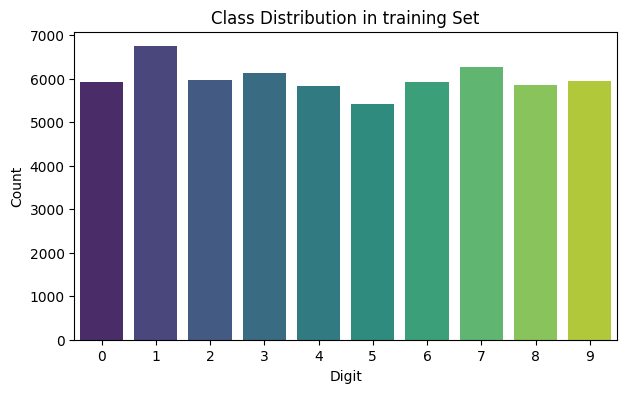

In [6]:
unique,counts = np.unique(y_train_full,return_counts=True)
class_dist = pd.Series(counts, index = unique)
print(class_dist)
plt.figure(figsize=(7,4))
sns.barplot(x=class_dist.index,y = class_dist.values,palette='viridis')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Class Distribution in training Set')
plt.show()

In [7]:
print("Min and Max pixel values are : [",x_train_full.min(),",",x_train_full.max(),"]")
x_train_flat = x_train_full.reshape(x_train_full.shape[0],-1).astype('float32')
x_test_flat = x_test.reshape(x_test.shape[0],-1).astype('float32')

print("Flattened train shape:",x_train_flat.shape,"and test shape:",x_test_flat.shape)

Min and Max pixel values are : [ 0 , 255 ]
Flattened train shape: (60000, 784) and test shape: (10000, 784)


*with this the data handling sect is done.*

***Feature Encoding, Scaling and TTS***

In [8]:
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.model_selection import train_test_split



# # this cell is for testing (i am testing the encoder because i forgor)
# kl = pd.DataFrame({'Color':['Red','Blue','Yellow']})
# encd = OneHotEncoder(sparse_output=False)
# model_test= encd.fit_transform(kl[['Color']])
# encd_kl= pd.DataFrame(model_test,columns=encd.get_feature_names_out(['Color']) )
# print(encd_kl) # Nice

scalar = MinMaxScaler()
x_train_scalar = scalar.fit_transform(x_train_flat)
x_test_scalar = scalar.transform(x_test_flat)



In [9]:
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train_full.reshape(-1,1))
y_test_encoded = encoder.fit_transform(y_test.reshape(-1,1))

print("Encoded label shape:",y_train_encoded.shape,"\nClassses learned by encoder:",encoder.categories_)

Encoded label shape: (60000, 10) 
Classses learned by encoder: [array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)]


In [10]:
x_train,x_val,y_train,y_val = train_test_split(
    x_train_scalar,y_train_encoded,
    test_size = 0.15,
    random_state= 42,
    stratify=y_train_full
)

print("Train:",x_train.shape,y_train.shape,"\nVal:",x_val.shape,y_val.shape,"\nTest:\n",x_test_scalar,y_test_encoded.shape)

Train: (51000, 784) (51000, 10) 
Val: (9000, 784) (9000, 10) 
Test:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] (10000, 10)


In [16]:
from tensorflow._api.v2.config import optimizer
def build_ann_model(input_dim = 784,num_classes= 10):
  model = keras.Sequential([
      layers.Input(shape=(input_dim,)),
      layers.Dense(256,activation = 'relu'),
      layers.Dropout(0.2),
      layers.Dense(128,activation = 'relu'),
      layers.Dropout(0.2),
      layers.Dense(64,activation = 'relu'),
      layers.Dense(num_classes,activation='softmax')
  ])
  model.compile(
      optimizer= 'adam',
      loss = 'categorical_crossentropy',
      metrics = ['accuracy']
      )
  return model

In [17]:
ann_model = build_ann_model()
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',patience = 5,restore_best_weights = True
) # a function for early stop

In [19]:
history = ann_model.fit(
    x_train,y_train,
    validation_data= (x_val,y_val),
    epochs = 50,
    batch_size = 128,
    callbacks=[early_stop],
    verbose = 1
)

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8840 - loss: 0.3880 - val_accuracy: 0.9542 - val_loss: 0.1542
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9553 - loss: 0.1509 - val_accuracy: 0.9652 - val_loss: 0.1139
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9668 - loss: 0.1073 - val_accuracy: 0.9716 - val_loss: 0.0916
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9738 - loss: 0.0862 - val_accuracy: 0.9761 - val_loss: 0.0890
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9779 - loss: 0.0733 - val_accuracy: 0.9758 - val_loss: 0.0826
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9804 - loss: 0.0608 - val_accuracy: 0.9774 - val_loss: 0.0745
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9821 - loss: 0.0560 - val_accuracy: 0.9774 - val_loss: 0.0821
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9837 - loss: 0.0502 - val_accuracy: 0

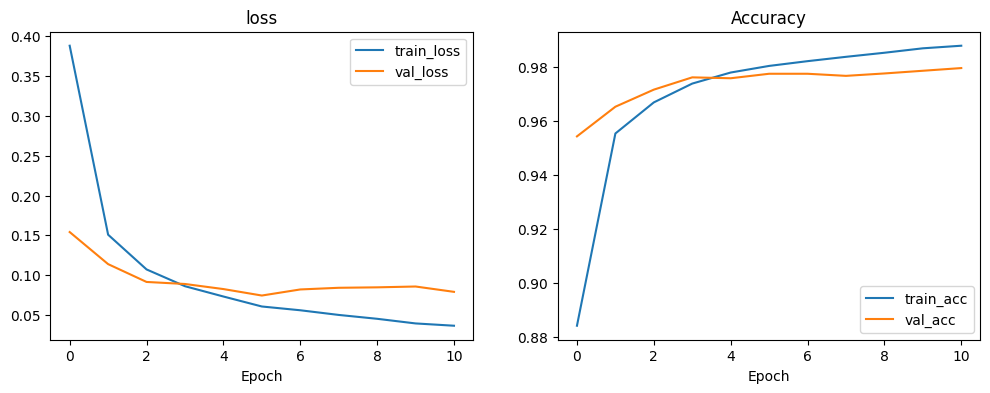

In [25]:
fig,ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(history.history['loss'],label = 'train_loss')
ax[0].plot(history.history['val_loss'],label= 'val_loss')
ax[0].set_title('loss');ax[0].set_xlabel('Epoch');ax[0].legend()

ax[1].plot(history.history['accuracy'],label = 'train_acc')
ax[1].plot(history.history['val_accuracy'],label ='val_acc')
ax[1].set_title('Accuracy');ax[1].set_xlabel('Epoch');ax[1].legend()
plt.show()